#### 1. Predict

In [1]:
import torch
import pandas as pd
import numpy as np
import tensorflow as tf


from utils.general import ViewDataMO
from model.heterogeneous_siamese_sider import siamese_model_sider_adr_emb

import os
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

2025-09-21 06:16:37.424035: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-21 06:16:37.640843: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-21 06:16:37.696377: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-21 06:16:38.723401: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; 

In [ ]:
dim_drug_x = 389
test_y = pd.read_csv("/home/datahouse1/liujin/HetSia-SafeNet/Data/ADR_multitask_dataset_random_split/AC50_Cmax/test_y.csv")

def data_parse(data_ds):
    l = []
    lbls = []
    task_numbers_list = []
    smiles_list = []
    task_name_list = []
    for i , data in enumerate(data_ds):
        smiles, embbed_drug, lbl, task_number, task_name = data
        l.append(embbed_drug)
        lbls.append(lbl)
        task_numbers_list.append(task_number)
        smiles_list.append(smiles)
        task_name_list.append(task_name)
        
    l = np.array(l).reshape(-1,dim_drug_x,1) #分子表征
    lbls = np.array(lbls)
    task_index = np.array(task_numbers_list).reshape(-1,1)
    return l,lbls,task_index,smiles_list,task_name_list

def predict_to_df(smiles_list, tasks_list, test_pred,drugname_smiles_dict):
    test_pred_df = pd.DataFrame(columns=['Drug','smiles', 'task_name', 'pred', 'label'])
    test_pred_df['smiles'] = smiles_list
    test_pred_df['Drug'] = test_pred_df['smiles'].map(drugname_smiles_dict)
    test_pred_df['task_name'] = tasks_list
    test_pred_df['pred'] = test_pred.reshape(-1)
    test_pred_df['label'] = test_pred_df['pred'].apply(lambda x: 1 if x > 0.5 else 0)
    return test_pred_df

In [ ]:
best_model = tf.keras.models.load_model('/home/datahouse1/liujin/HetSia-SafeNet/result_split/property_feature_adr_emb_scaffold/AC50_Cmax/best_model')
# best_model = tf.keras.models.load_model('/home/datahouse1/liujin/HetSia-SafeNet/result_split/property_feature_adr_emb_random/AC50_Cmax/best_model')
df_o = pd.read_csv("/home/datahouse1/liujin/HetSia-SafeNet/Data/investigational_drugs/drugs_info.csv")
drugname_smiles_dict = dict(zip(df_o["canonical_smiles"], df_o["drug_name"]))

for dose in ["5mg","10mg","25mg","50mg","75mg","100mg","125mg","150mg","200mg","250mg","300mg","350mg"]:
    test_X_dose = pd.read_csv(f"/home/datahouse1/liujin/HetSia-SafeNet/Data/investigational_drugs/dose_study_offcmax/predict_X_{dose}.csv")
    adr_list = test_y.columns[1:].tolist()
    smiles_list = test_X_dose["smiles"].tolist()
    adr_list.insert(0,"smiles")

    test_y_predict = pd.DataFrame(columns=adr_list)
    test_y_predict["smiles"] = smiles_list
    test_y_predict.iloc[:,1:] = 0

    # Thought: Observe the change in the predicted value corresponding to the increase in dosage (the impact of Cmax increase on the safety of the compound)
    test_X_dose_pro = ViewDataMO(test_X_dose, test_y_predict)
    l_test_dose, lbls_test_dose, task_index_test_dose, smiles_list_dose, tasks_list_dose = data_parse(test_X_dose_pro)

    # Data prediction
    test_pred_dose = best_model.predict([l_test_dose, task_index_test_dose], verbose=1)

    # Save the prediction results
    test_pred_df_dose = predict_to_df(smiles_list_dose, tasks_list_dose, test_pred_dose, drugname_smiles_dict)
    test_pred_df_dose.to_csv(f'/home/datahouse1/liujin/HetSia-SafeNet/Data/investigational_drugs/dose_study_offcmax/scaffold_predict_result/pred_{dose}.csv',index=False)

308/308 [==============================] - 2s 6ms/step


#### 2. Visualization

In [ ]:
import pandas as pd
import numpy as np
from collections import defaultdict

pred_df_5mg = pd.read_csv('//home/datahouse1/liujin/HetSia-SafeNet/Data/investigational_drugs/dose_study_offcmax/scaffold_predict_result/pred_5mg.csv')
pred_df_10mg = pd.read_csv('/home/datahouse1/liujin/HetSia-SafeNet/Data/investigational_drugs/dose_study_offcmax/scaffold_predict_result/pred_10mg.csv')
pred_df_25mg = pd.read_csv('/home/datahouse1/liujin/HetSia-SafeNet/Data/investigational_drugs/dose_study_offcmax/scaffold_predict_result/pred_25mg.csv')
pred_df_50mg = pd.read_csv('/home/datahouse1/liujin/HetSia-SafeNet/Data/investigational_drugs/dose_study_offcmax/scaffold_predict_result/pred_50mg.csv')
pred_df_75mg = pd.read_csv('/home/datahouse1/liujin/HetSia-SafeNet/Data/investigational_drugs/dose_study_offcmax/scaffold_predict_result/pred_75mg.csv')
pred_df_100mg = pd.read_csv('/home/datahouse1/liujin/HetSia-SafeNet/Data/investigational_drugs/dose_study_offcmax/scaffold_predict_result/pred_100mg.csv')
pred_df_125mg = pd.read_csv('/home/datahouse1/liujin/HetSia-SafeNet/Data/investigational_drugs/dose_study_offcmax/scaffold_predict_result/pred_125mg.csv')
pred_df_150mg = pd.read_csv('/home/datahouse1/liujin/HetSia-SafeNet/Data/investigational_drugs/dose_study_offcmax/scaffold_predict_result/pred_150mg.csv')
pred_df_200mg = pd.read_csv('/home/datahouse1/liujin/HetSia-SafeNet/Data/investigational_drugs/dose_study_offcmax/scaffold_predict_result/pred_200mg.csv')
pred_df_250mg = pd.read_csv('/home/datahouse1/liujin/HetSia-SafeNet/Data/investigational_drugs/dose_study_offcmax/scaffold_predict_result/pred_250mg.csv')


adr_type_list = list(pred_df_5mg['task_name'].unique())
print(len(adr_type_list))
print(adr_type_list)
# Drug,smiles,task_name,pred,label

18
['Blood and lymphatic system disorders', 'Cardiac disorders', 'Ear and labyrinth disorders', 'Endocrine disorder', 'Eye disorders', 'Gastrointestinal disorders', 'Hepatobiliary disorders', 'Immune system disorders', 'Infections and infestations', 'Metabolism and nutrition disorders', 'Musculoskeletal and connective tissue disorders', 'Nervous system disorders', 'Psychiatric disorders', 'Renal and urinary disorders', 'Reproductive system and breast disorders', 'Respiratory, thoracic and mediastinal disorders', 'Skin and subcutaneous tissue disorders', 'Vascular disorders']


In [ ]:
def drug_pred_get(drug_name, pred_df):
    drug_pred_result_dict = {}
    pred_df = pred_df[pred_df['Drug'] == drug_name]
    # Construct {"Drug": {"ADR1": pred, "ADR2": pred, ...}, ...}
    for index, row in pred_df.iterrows():
        drug_pred_result_dict[row['task_name']] = row['pred']
    return drug_pred_result_dict

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
def dose_analys_pic_get(drugname, pred_result_dict):
    doses = list(pred_result_dict.keys())
    # adr_labels = list(pred_result_dict["100mg"].keys())  # 18 types of ADR category labels
    adr_labels = list(pred_df_5mg['task_name'].unique())

    # Put the probabilities in a dictionary, with the key being the dose and the value being 18 predicted probabilities
    data = {dose: [pred_result_dict[dose][adr] for adr in adr_labels] for dose in doses}

    num_adr = len(adr_labels)
    angles = np.linspace(0, 2 * np.pi, num_adr, endpoint=False).tolist()
    angles += angles[:1]

    # Draw a radar chart
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True), dpi=300)
    ax.set_position([0.2, 0.2, 0.9, 0.9])
    
    hex_colors = ['#a6cee3','#1f78b4','#b2df8a','#33a02c','#fb9a99']
    # #cab2d6,250mg; #ff7f00,200mg;#fdbf6f,150mg; #e31a1c,100mg;#fb9a99,75mg;#33a02c,50mg;#b2df8a,25mg;#1f78b4,10mg;#a6cee3,5mg
    colors = [mcolors.to_rgb(color) for color in hex_colors]

    # Draw the radar lines for each dose
    for dose, color in zip(doses, colors):
        values = data[dose]
        values += values[:1]
        ax.plot(angles, values, color=color, linewidth=2, label=dose, marker='o', markersize=4)
        ax.fill(angles, values, color=color, alpha=0.25)

    # Set labels
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", fontsize=16)
    ax.set_xticks(angles[:-1])
    adr_labels = [label.replace('_', ' ') for label in adr_labels]
    adr_labels = [label[:3] for label in adr_labels]
    ax.set_xticklabels(adr_labels, fontsize=18)
    if drugname[0].islower():
        drugname = drugname.capitalize()
    # Set the title and legend
    ax.set_title(f"Dose-Dependent ADR Probabilities of {drugname}", fontsize=20)
    # ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), title="Dose", fontsize=14)
    ax.legend(loc='lower left', bbox_to_anchor=(0.9, -0.08), fontsize=14) #lower left

    # Save picture
    plt.savefig(f"/home/datahouse1/liujin/HetSia-SafeNet/Data/investigational_drugs/pic_save/drug_dose_analysis/{drugname}_pred_adr.png", bbox_inches='tight')

##### Example1: Filgotinib（approved drugs, highly selective JAK1 inhibitor）

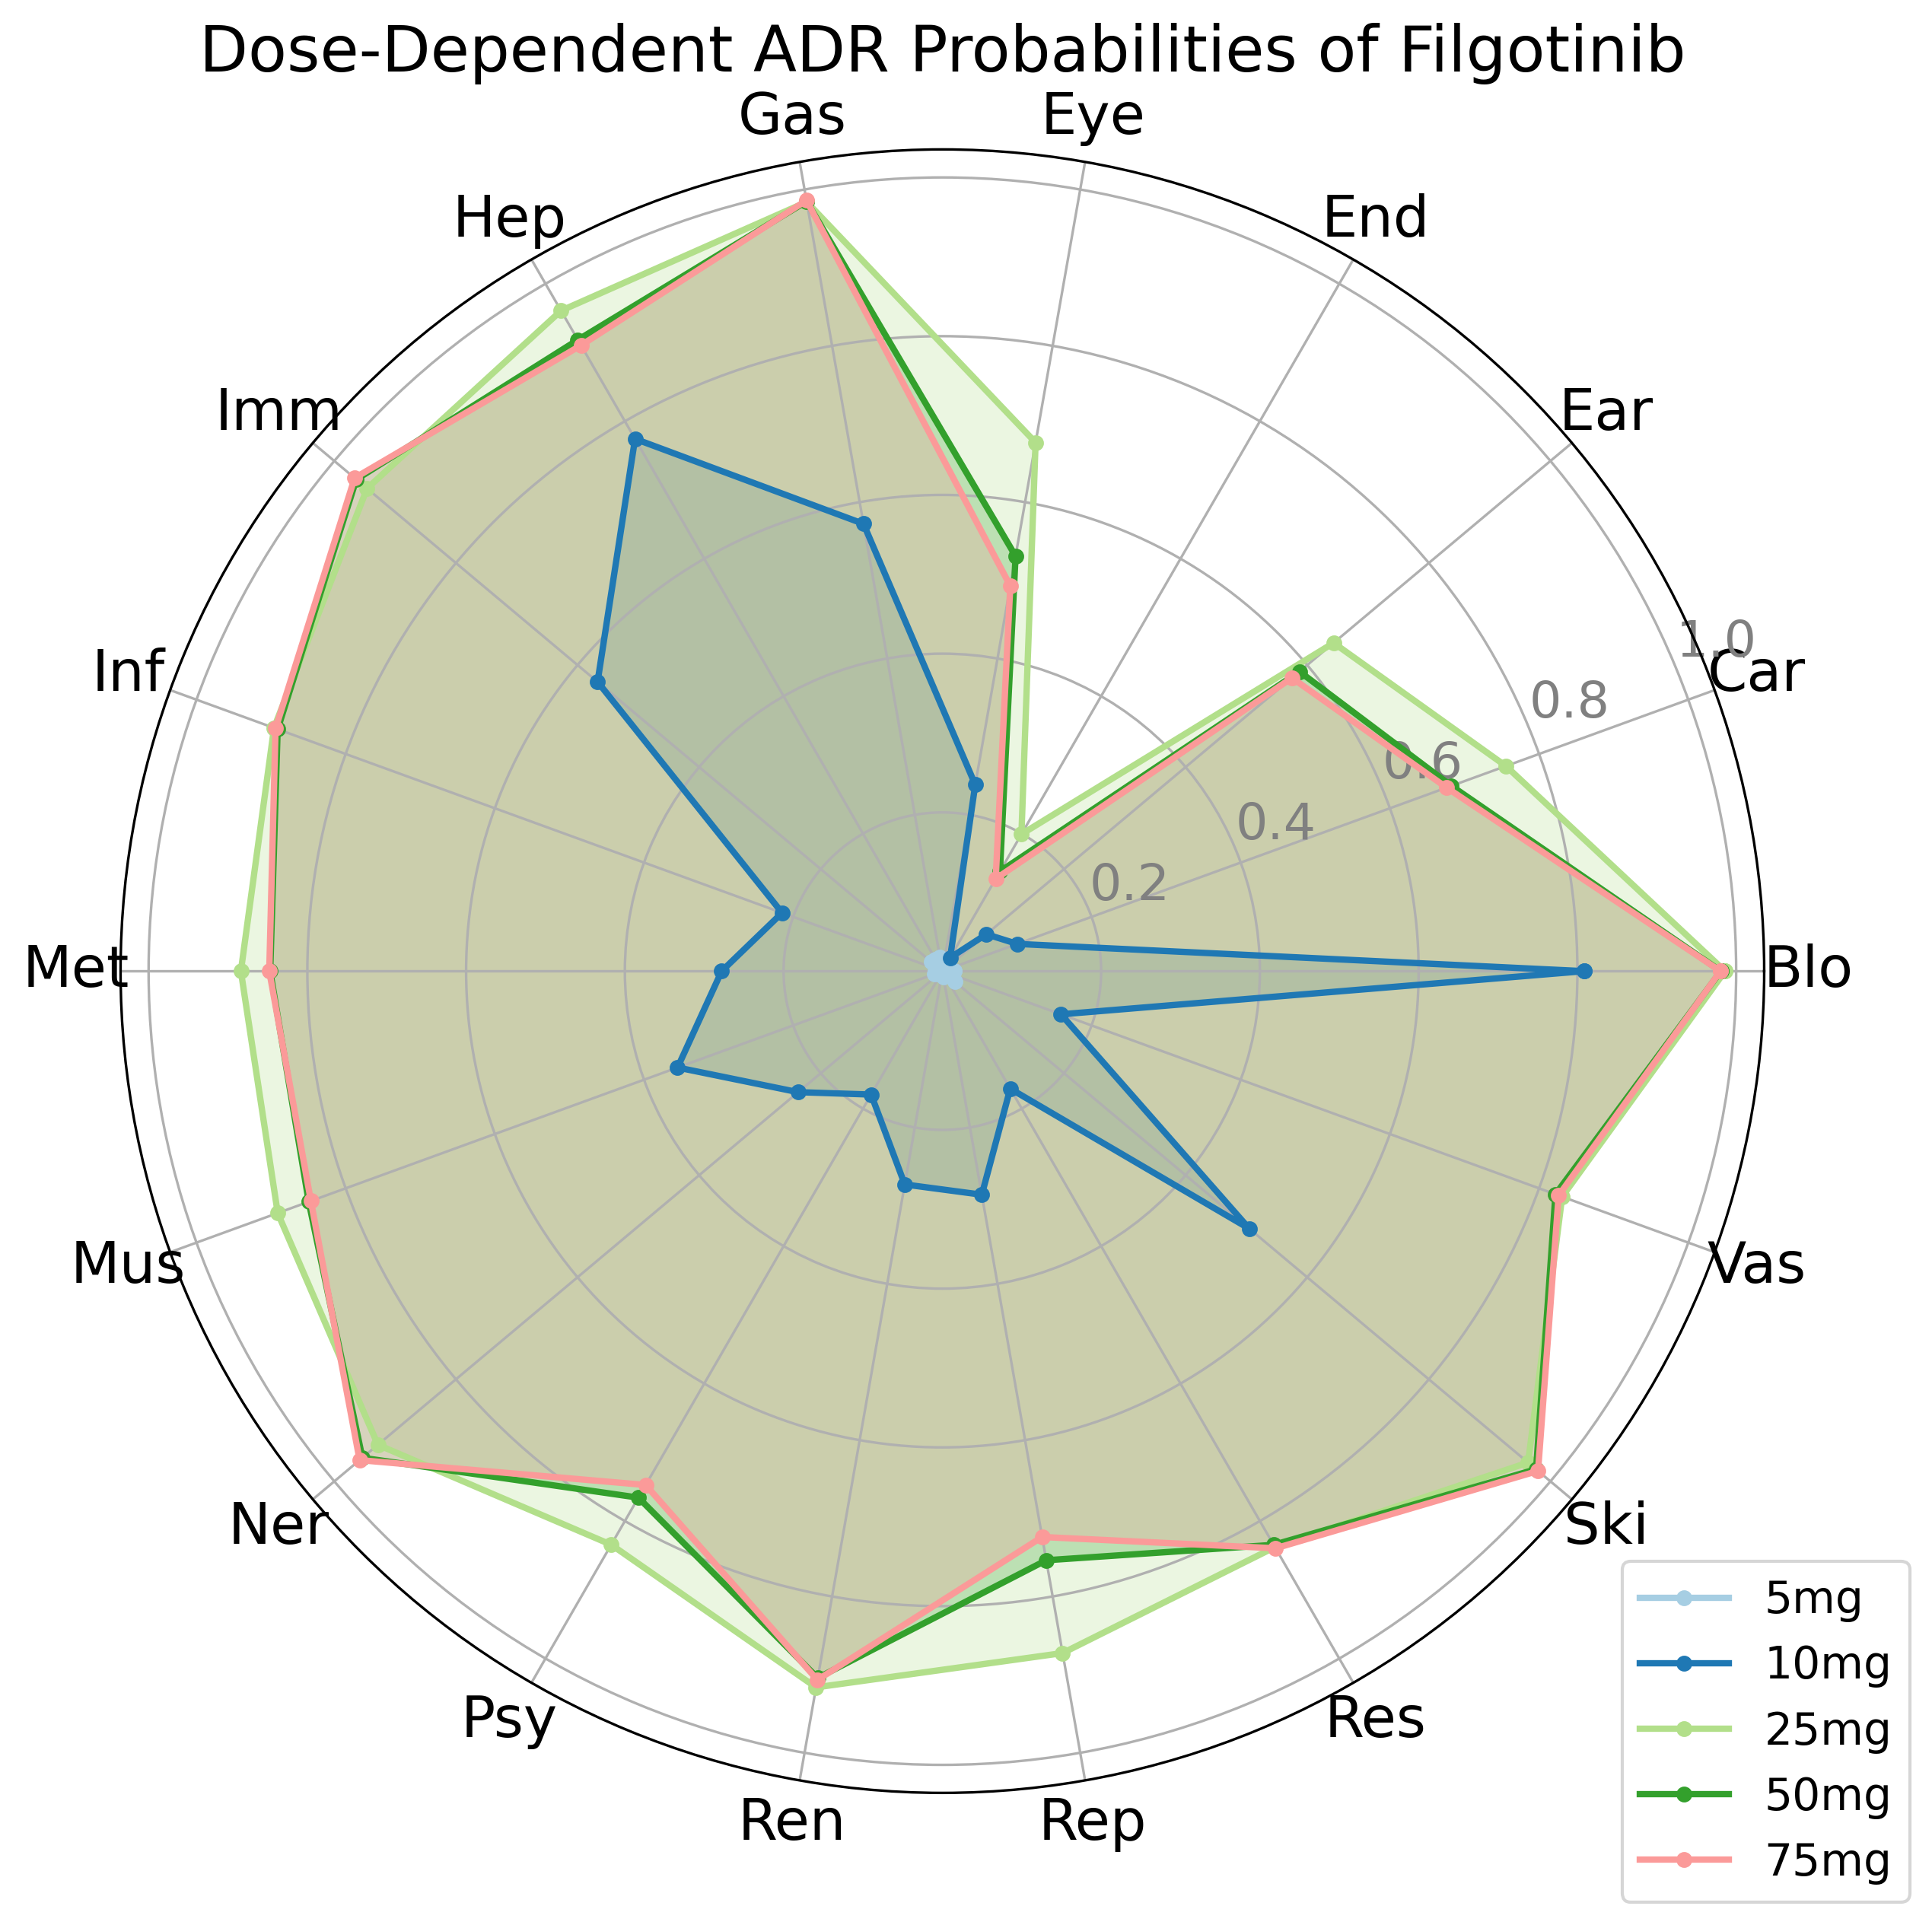

In [ ]:
filgotinib_pred_result_dict = defaultdict(dict)
filgotinib_pred_result_dict['5mg'] = drug_pred_get('Filgotinib', pred_df_5mg)
filgotinib_pred_result_dict['10mg'] = drug_pred_get('Filgotinib', pred_df_10mg)
filgotinib_pred_result_dict['25mg'] = drug_pred_get('Filgotinib', pred_df_25mg)
filgotinib_pred_result_dict['50mg'] = drug_pred_get('Filgotinib', pred_df_50mg)
filgotinib_pred_result_dict['75mg'] = drug_pred_get('Filgotinib', pred_df_75mg)
dose_analys_pic_get('Filgotinib', filgotinib_pred_result_dict)
# Also known as Jyseleca
# recommended dose 200 mg, older age (> 70) or is over 100 mg dose adjustment with renal impairment (dose need to achieve a balance between safety and efficacy) https://pmc.ncbi.nlm.nih.gov/articles/PMC9228886/
# It highly selectively inhibits JAK1, but has weak effects on JAK2, JAK3 and TYK2.

#### Example2: Piroxicam (An increase in dosage leads to an increase in toxicity)

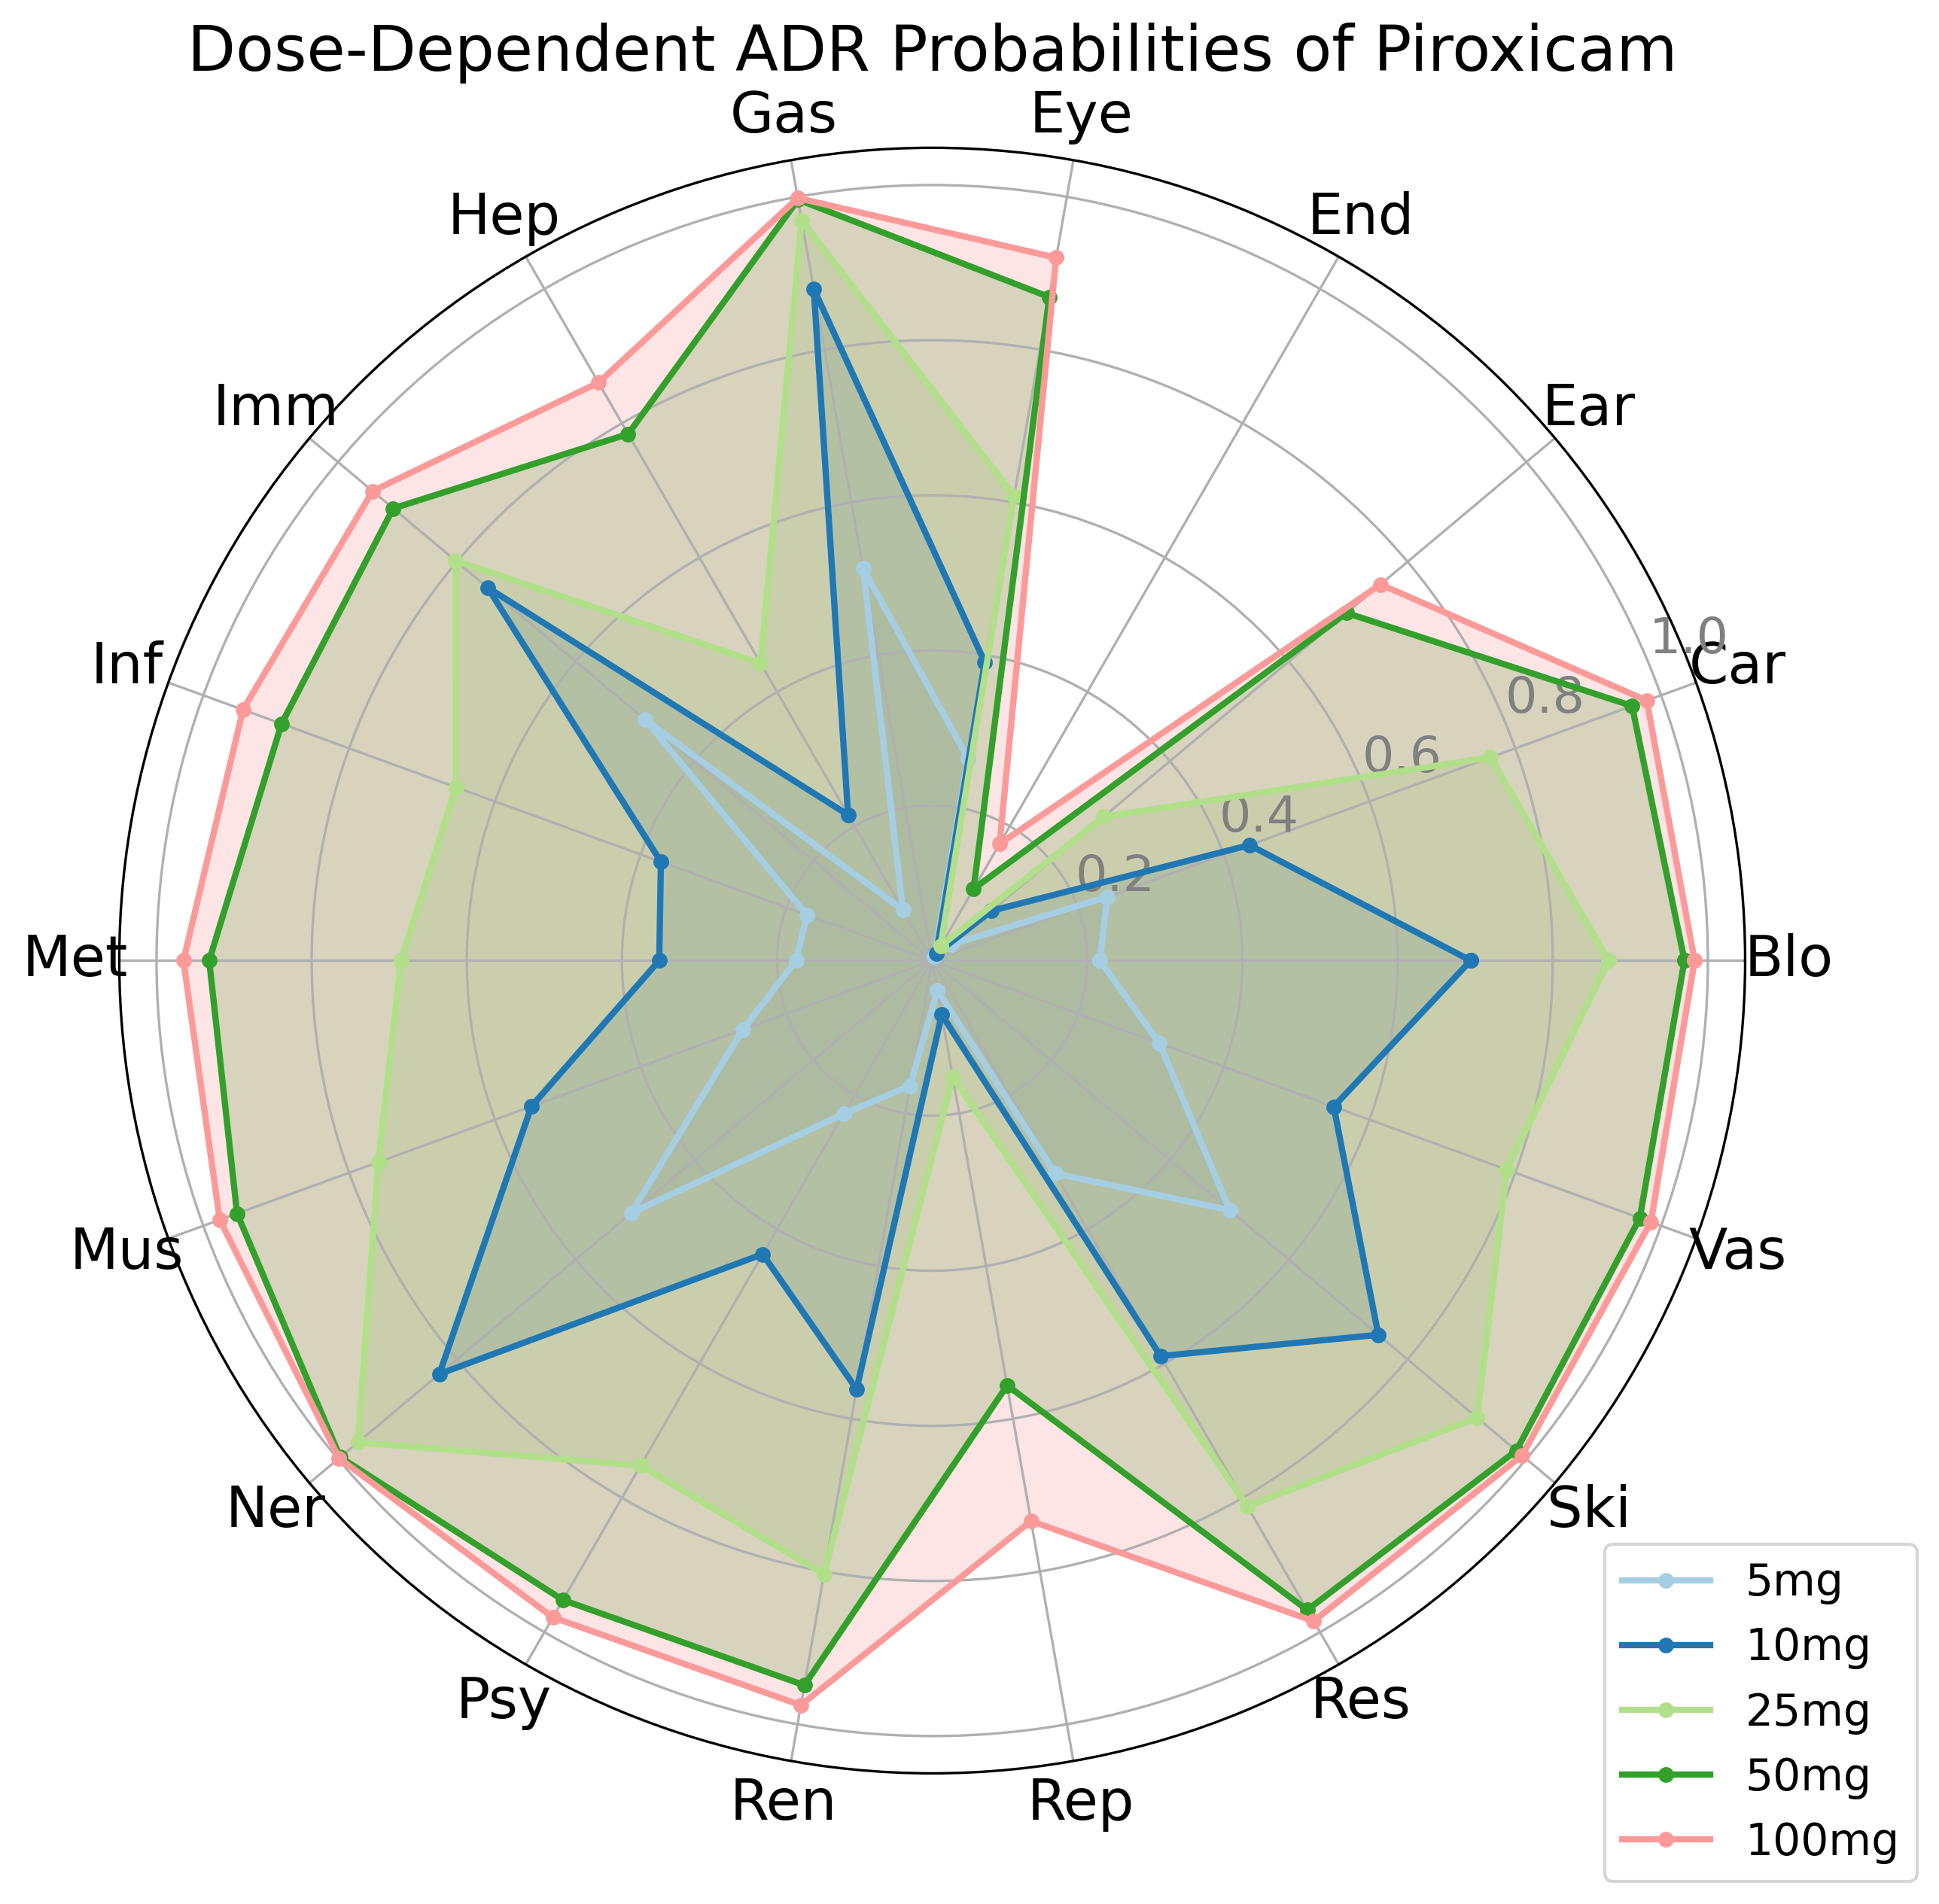

In [45]:
piroxicam_pred_result_dict = defaultdict(dict)
piroxicam_pred_result_dict['5mg'] = drug_pred_get('piroxicam', pred_df_5mg)
piroxicam_pred_result_dict['10mg'] = drug_pred_get('piroxicam', pred_df_10mg)
piroxicam_pred_result_dict['25mg'] = drug_pred_get('piroxicam', pred_df_25mg)
piroxicam_pred_result_dict['50mg'] = drug_pred_get('piroxicam', pred_df_50mg)
piroxicam_pred_result_dict['100mg'] = drug_pred_get('piroxicam', pred_df_100mg)
dose_analys_pic_get('piroxicam', piroxicam_pred_result_dict)
# 20 mg orally once a day，10 mg orally twice a day

In [49]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np

#### Example3: Pirprofen (hepatic, gastrointestinal---worldwide withdrawn)

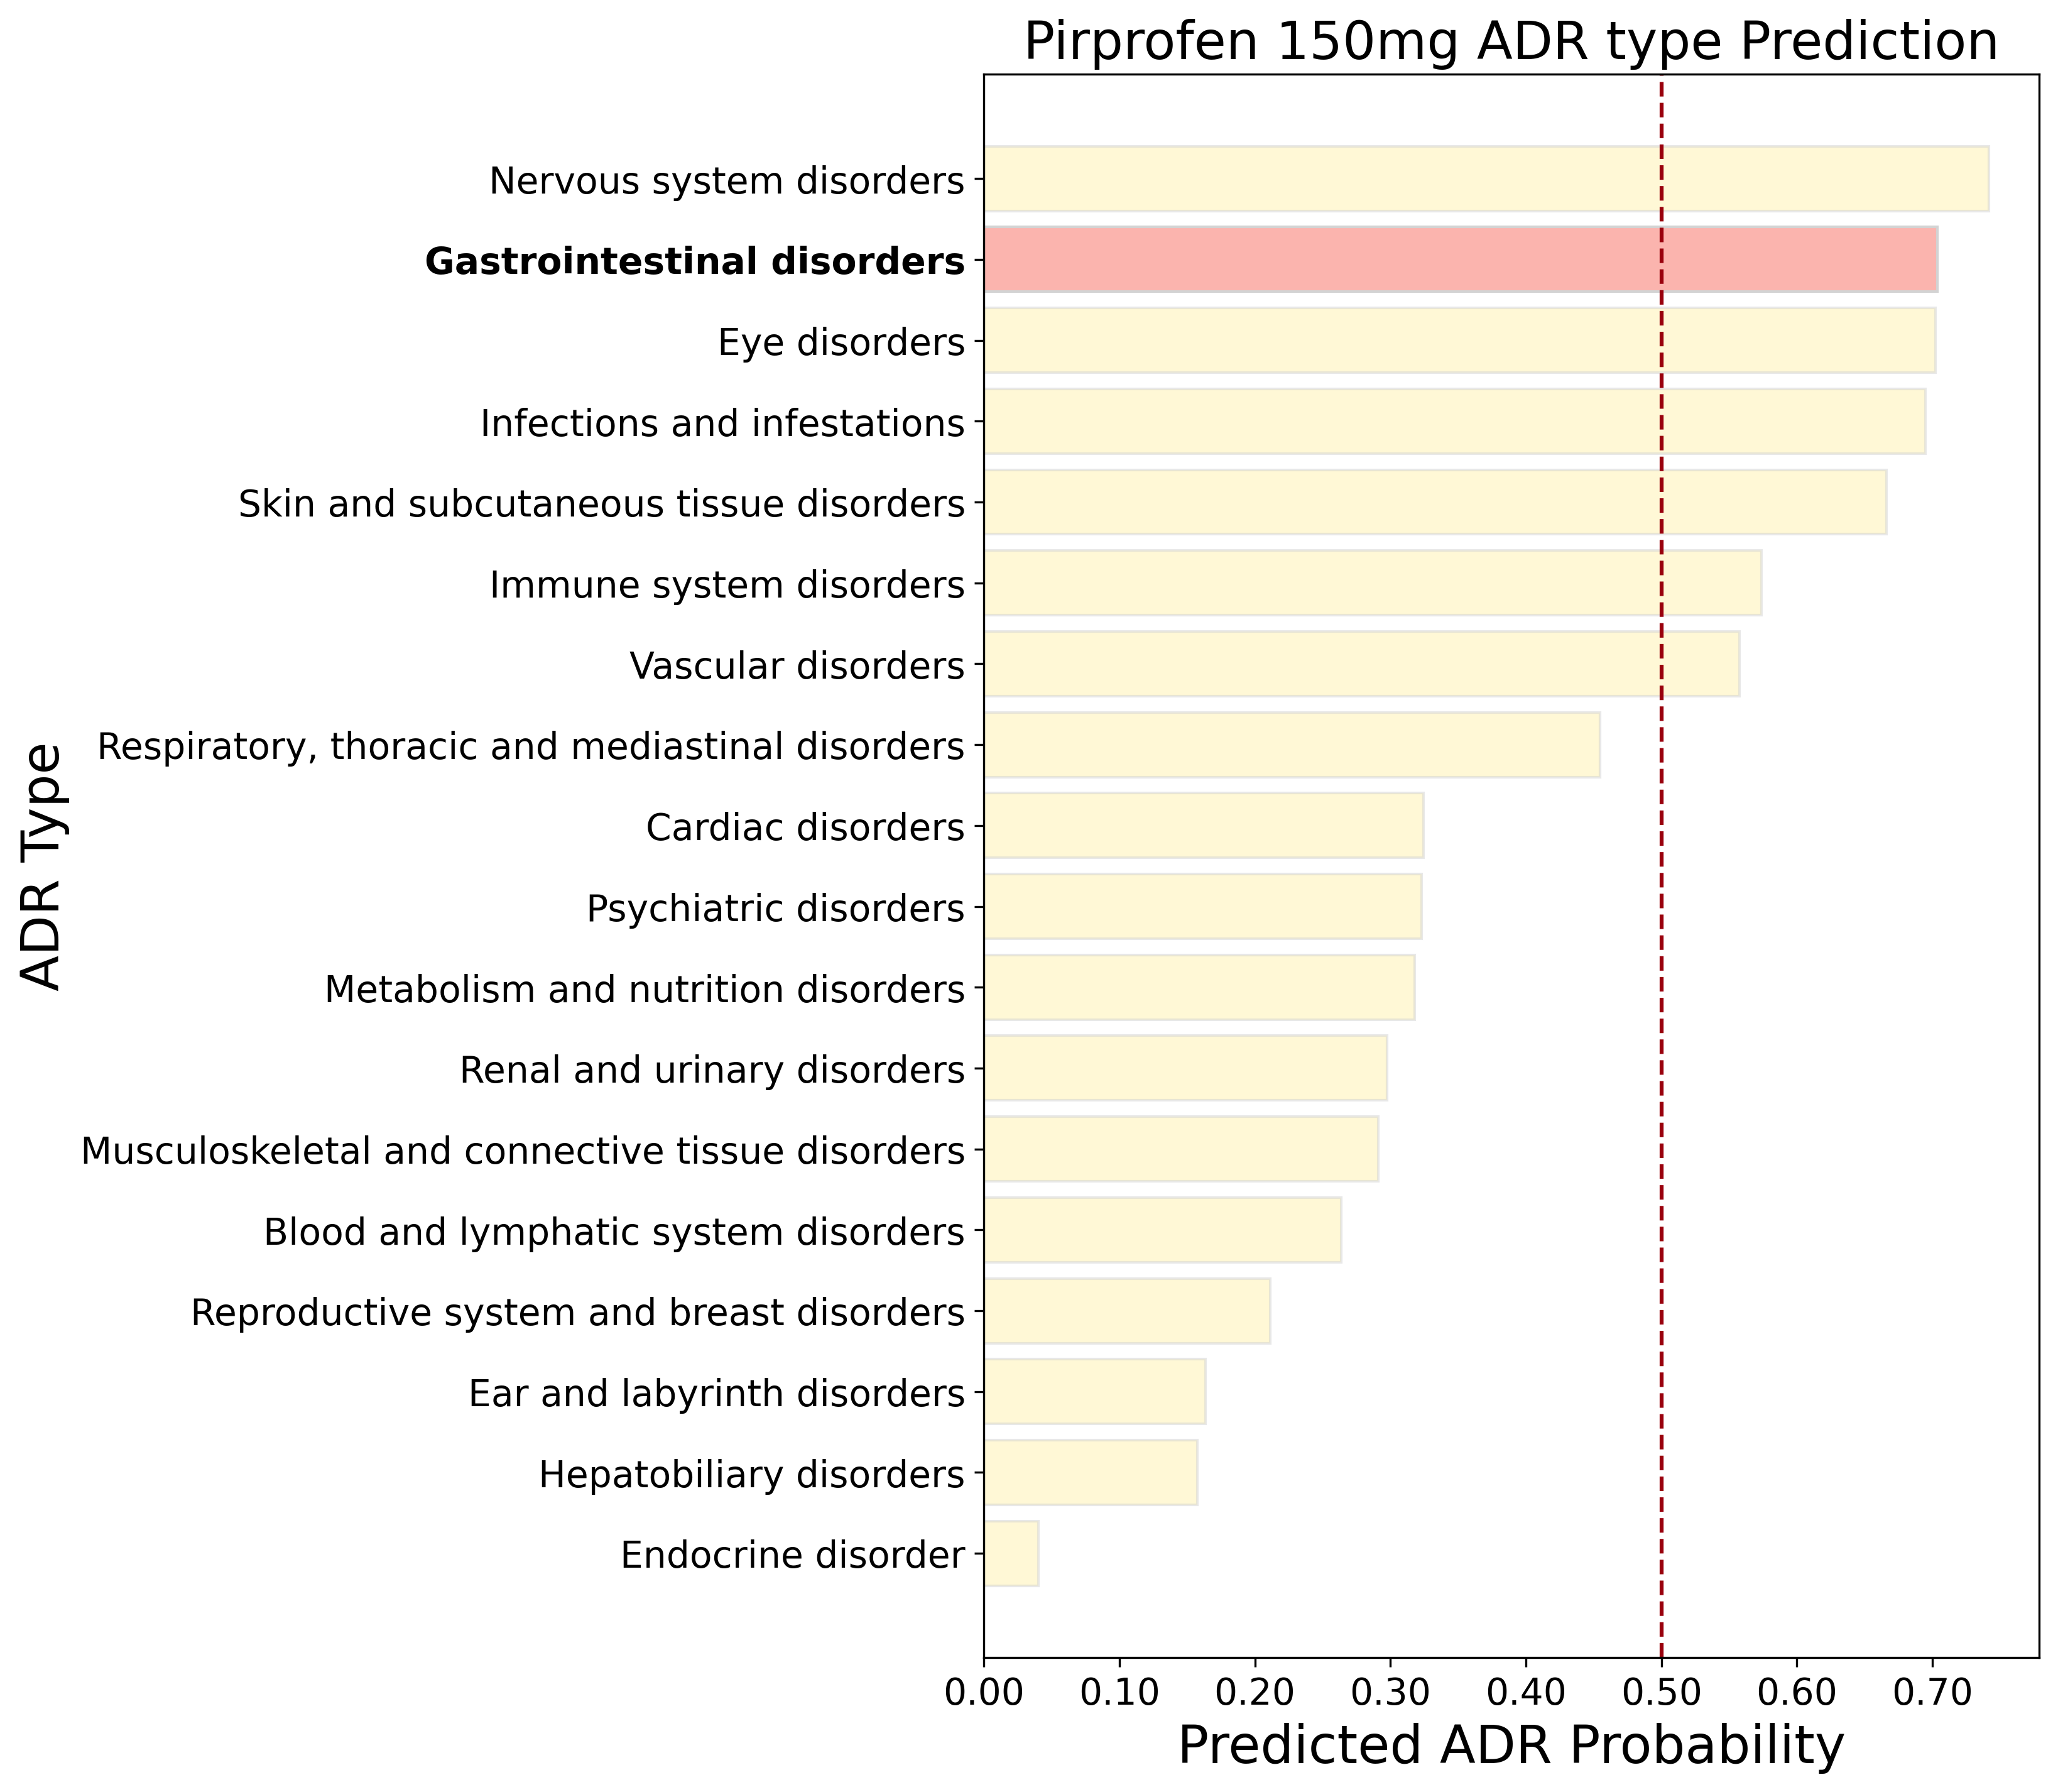

In [ ]:
## https://www.sciencedirect.com/topics/pharmacology-toxicology-and-pharmaceutical-science/indoprofen
# It was withdrawn from the market due to severe gastrointestinal bleeding and carcinogenicity
Pirprofen_predict_150mg = drug_pred_get('Pirprofen', pred_df_150mg)
Pirprofen_predict_150mg_df = pd.DataFrame.from_dict(Pirprofen_predict_150mg, orient='index', columns=['value'])
# Change the index column to the ADR_type column
Pirprofen_predict_150mg_df.reset_index(inplace=True)
Pirprofen_predict_150mg_df.rename(columns={'index': 'ADR_type'}, inplace=True)
Pirprofen_predict_150mg_df.sort_values(by='value', ascending=False, inplace=True)
Pirprofen_predict_150mg_df.reset_index(drop=True, inplace=True)

adr_term_sort = Pirprofen_predict_150mg_df['ADR_type'].tolist()[::-1]
# In adr_term_sort, change the element "_" to a space
adr_term_sort = [term.replace("_", " ") for term in adr_term_sort]
pred_value_sort = Pirprofen_predict_150mg_df['value'].tolist()[::-1]

fig,ax = plt.subplots(figsize=(8, 6), dpi=300)
# The column has a gray border
ax.barh(adr_term_sort, pred_value_sort, color='#fff2ae', edgecolor='lightgray', alpha=0.5)
plt.subplots_adjust(left=0.2, right=0.9, top=1.5, bottom=0.1, wspace=0.5, hspace=0.5)

ticks = ax.yaxis.get_major_ticks()
# select part of the ticks font bold
indices_to_bold = [17-1] #17-0,17-1,17-2
for i in indices_to_bold:
    ticks[i].label1.set_weight('bold')

indices_to_change_color = [17-1]
for i in indices_to_change_color:
    ax.patches[i].set_color('#fbb4ae')
    ax.patches[i].set_edgecolor('lightgray')
    ax.patches[i].set_alpha(1)

plt.xlabel('Predicted ADR Probability', fontsize=20)
plt.ylabel('ADR Type', fontsize=20)
plt.title('Pirprofen 150mg ADR type Prediction', fontsize=20)
formatter = ticker.FormatStrFormatter('%.2f')
plt.xticks(fontsize=14)
ax.xaxis.set_major_formatter(formatter)

plt.yticks(fontsize=14)
# add a vertical dotted line
plt.axvline(x=0.5, color='#99000d', linestyle='--')

plt.show()


#### Example4: Methopholine（withdrawal drugs）

In [ ]:
# opthalmic (ophthalmic toxicity) was withdrawn from the market in 1965. The recommended dose was 20-30mg, and 25mg was taken. Also known as Metofoline or methofoline
# https://gsrs.ncats.nih.gov/ginas/app/ui/substances/72L4ZT2W1P
methopholine_predict_25mg = drug_pred_get('Methopholine', pred_df_25mg)
methopholine_predict_25mg_df = pd.DataFrame.from_dict(methopholine_predict_25mg, orient='index', columns=['value'])
methopholine_predict_25mg_df.reset_index(inplace=True)
methopholine_predict_25mg_df.rename(columns={'index': 'ADR_type'}, inplace=True)
methopholine_predict_25mg_df.sort_values(by='value', ascending=False, inplace=True)
methopholine_predict_25mg_df.reset_index(drop=True, inplace=True)
methopholine_predict_25mg_df.head(18)

,ADR_type,value
0,Gastrointestinal disorders,0.410023
1,Nervous system disorders,0.367156
2,Cardiac disorders,0.319550
3,Eye disorders,0.308956
4,Skin and subcutaneous tissue disorders,0.295331
5,Vascular disorders,0.275571
6,"Respiratory, thoracic and mediastinal disorders",0.268521
7,Immune system disorders,0.256169
8,Psychiatric disorders,0.146848
9,Metabolism and nutrition disorders,0.138440


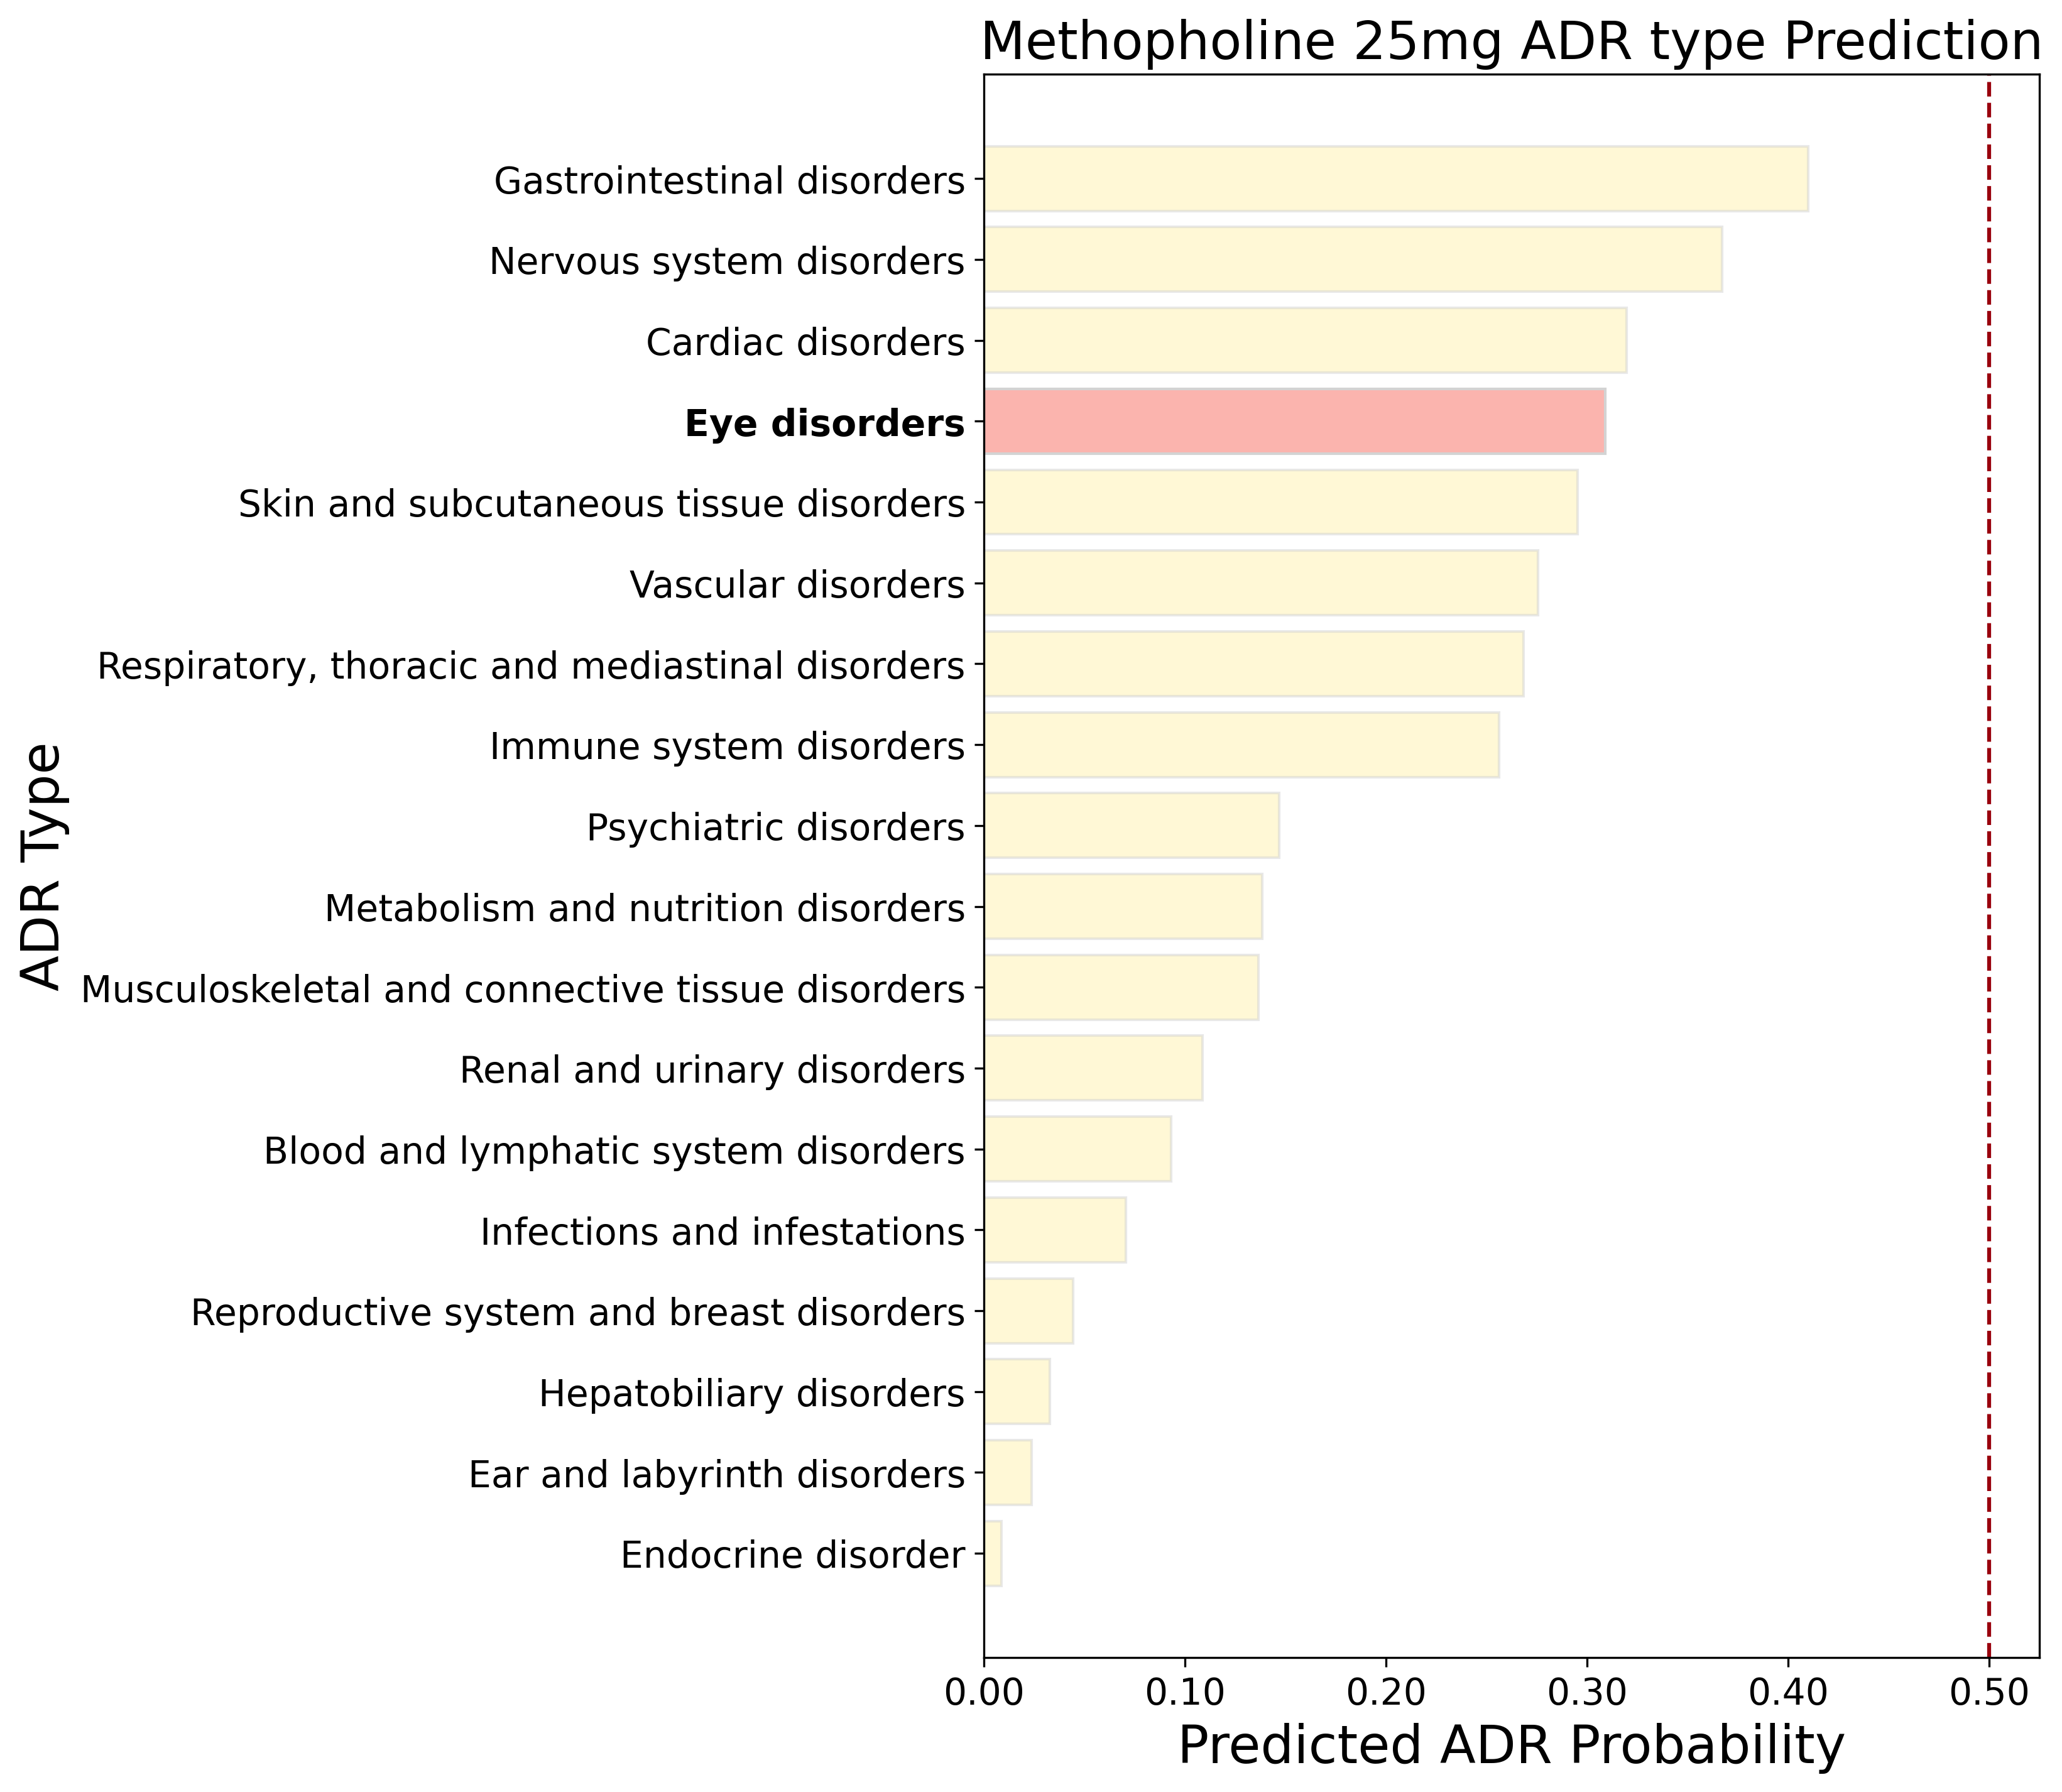

: 

In [ ]:
adr_term_sort = methopholine_predict_25mg_df['ADR_type'].tolist()[::-1]
adr_term_sort = [term.replace("_", " ") for term in adr_term_sort]
pred_value_sort = methopholine_predict_25mg_df['value'].tolist()[::-1]

fig,ax = plt.subplots(figsize=(8, 6), dpi=300)
ax.barh(adr_term_sort, pred_value_sort, color='#fff2ae', edgecolor='lightgray', alpha=0.5) # #fbb4ae红色
plt.subplots_adjust(left=0.2, right=0.9, top=1.5, bottom=0.1, wspace=0.5, hspace=0.5)

ticks = ax.yaxis.get_major_ticks()
# select part of the ticks font bold
indices_to_bold = [17-3,] #17-0,17-1,17-2
for i in indices_to_bold:
    ticks[i].label1.set_weight('bold')

indices_to_change_color = [17-3,]
for i in indices_to_change_color:
    ax.patches[i].set_color('#fbb4ae')
    ax.patches[i].set_edgecolor('lightgray')
    ax.patches[i].set_alpha(1)

plt.xlabel('Predicted ADR Probability', fontsize=20)
plt.ylabel('ADR Type', fontsize=20)
plt.title('Methopholine 25mg ADR type Prediction', fontsize=20)
formatter = ticker.FormatStrFormatter('%.2f')
plt.xticks(fontsize=14)
ax.xaxis.set_major_formatter(formatter)

plt.yticks(fontsize=14)
# add a vertical dotted line
plt.axvline(x=0.5, color='#99000d', linestyle='--')

plt.show()